In [1]:
import simpy
import numpy as np
import sys
sys.path.append('../../sim_course_pycharm')
sys.path.append(r'C:\Users\Eshel\workspace\butools2\Python')
import pandas as pd
import os
from IPython.display import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
from sample_PH import *
from utils import *
import time
from project_utils import *
import numpy as np 

<div dir = 'rtl'>
    
# ברוכים הבאים לפרויקט מסכם

### בפרויקט זה אתם מנהלים בחברת תקשורת גדולה.
    
### אתם אחראים ניהול הcall center של המערכת
    
### במערכת call center יש שלושה סוגים שונים של עובדים: עוזר זוטר, עובד בכיר ומנהל תקשורת

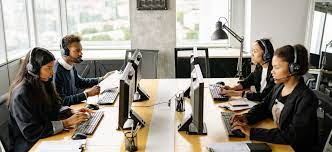

In [5]:
Image('../Images/callcenter.jpg', width=420)

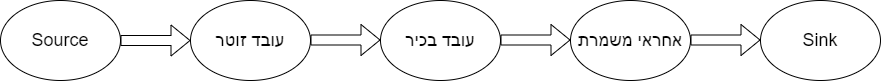

In [6]:
Image('../Images/sim_project.png', width=820)

<div dir = 'rtl'>

## בחברה יש עובד זוטר עובד בכיר ואחראי משמרת. כל הטלפונים מגיעים קודם לעובד הזוטר. בהסתברות $p12$ הוא לא מצליח לפתור את הבעיה של הלקוח ומעביר את השיחה לעובד הבכיר. בהסתברות $p23$ העובד הבכיר לא מצליח לפתור את הבעיה ושולח את הלקוח לאחראי משמרת. האחראי משמרת בהסתברות $p32$ ישלח את הלקוח לעובד הבכיר שוב. גם לקוח שחזר שוב לעובד הבכיר יחזור לאחראי משמרת בהסתברות $p23$.
    
### בתוך p_trans יש מטריצת של הסתברויות מעבר. 
    
### למשל הערך באינדקס [0,1] זו ההסתברות $p12$ כלומר לעבור מעובד זוטר לעובד בכיר. 

### השורה הראשונה מייצגת את העובד הזוטר, השנייה את הבכיר ושלישית את אחראי משמרת. השורות מייצגות את המקור ועמודות את היעד. 

In [15]:
project_num = 5
p_trans = pkl.load( open('../pkls/ptrans_group_'+ str(project_num) +'.pkl','rb'))
p_trans

array([[0.        , 0.26022469, 0.        ],
       [0.        , 0.        , 0.26587276],
       [0.        , 0.08710111, 0.        ]])

<div dir = 'rtl'>

## לפניך אוביקט שמכיל רשימה של 3 dataframes. באינדקס 0 זה תור לעובד זוטר, אינדקס 1 תור לעובד בכיר ואינקדס 2 אחראי משמרת. כל אחד מהם יש בו 3 עמודות:
    
### Event: מציין האם הייתה הגעה, כניסה לשירות או סיום שירות.
    
### Time: מציין את זמן הארוע
    
### Customer: מספר סידורי של הצרכן

In [17]:
project_num = 5
df_events_all_stations = pkl.load( open('../pkls/df_data_group_' + str(project_num)+'.pkl', 'rb'))

In [18]:
df_events_all_stations = pkl.load( open('../pkls/df_data_group_' + str(project_num)+'.pkl', 'rb'))

# זוטר: 
df_events_all_stations[0].head(15)

,Customer,Event,Time
0,3,Arrival,0.269187
1,3,Enter service,0.269187
2,4,Arrival,0.295367
3,8,Arrival,0.534503
4,3,Departure,0.702923
5,4,Enter service,0.702923
6,10,Arrival,0.744765
7,4,Departure,0.947752
8,8,Enter service,0.947752
9,8,Departure,1.283523


In [19]:
# בכיר: 
df_events_all_stations[1].head()

,Customer,Event,Time
0,2,Arrival,0.196355
1,2,Enter service,0.196355
2,7,Arrival,0.461795
3,12,Arrival,1.404774
4,14,Arrival,1.730196


In [20]:
# אחראי משמרת: 
df_events_all_stations[2].head(5)

,Customer,Event,Time
0,1,Arrival,0.157800
1,1,Enter service,0.157800
2,5,Arrival,0.328043
3,6,Arrival,0.425840
4,9,Arrival,0.559640


<div dir = 'rtl'>

    
# משימות:
    
## 1. יש למצוא התפלגות זמני שירות בכל אחד מהתורים וזמנים בין הגעה תור הזוטר. הכוונה היא להתאים התפלגות אנלטית כלשהי.
    
## 2. מהי הנצילות בכל תור?
    
## 3. כפי שצוין למעלה הסתברויות מעבר ידועות. נניח כעת כי ניתן לשנות את $p12$. מה יהיה $p12$ הכי גבוה כך שהנצילות בכל התורים לא תעלה על 0.8. 
    
## 4. נא לבנות סימולציה בSimpy על סמך ההתפלגויות שמצאת והסתברות מעבר שקיבלתם.
    
## 5. יש למצוא זמן סימולציה כך שר"ס של אורך זמן שהייה בכל המערכת לא יעלה על 0.5 ברמת ביטחון של 0.95
    
## 6. נניח כי ניתן להקטין את $p12$ מהערך הנוכחי ב0.03. כיצד זה ישפיע על על ההסתברות ל-3 צרכנים במערכת של הבכיר? 
    
## 7.  האם יש תחנות שזה לא ישפיע עליהם בכלל? מדוע?
    
## 8. נעשה כעת שינוי במערכת, במקום לדגום זמן של שירות של עובד זוטר על סמך ההתפלגות שהתאמתם בסעיף 1, מה תהיה התפלגות זמן שהייה אם נחליף את אותה התפלגות במעריכית כאשר הפרמטר שלה הוא לפי תוחלת ההתפלגות שהתאמתם בסעיף 1? האם זמן שהייה הממוצע אצל הזוטר עלה ביחס למקור או ירד? מדוע חל שינוי דווקא בכיוון הזה?
    
## 9. נא לחשב את האחוזון ה95 של התפלגות זמן השהייה בזוטר תחת השירות המעריכי בסעיף 8. 
    
## 10. בחברה רוצים לצמצם זמני המתנה. הפחתה של זמן שהייה ממוצע במערכת כולה ביחידה בודדת (כלומר זמן שהייה מהרגע שבו צרכן הגיע לתור של עובד זוטר עד אשר עזב את המערכת) שווה להנהלה 30 אלף ש"ח. כמה תהיו מוכנים לשלם עבור עובד זוטר שלא שולח בכלל לבכיר (כלומר מטפל בעצמו)?


    
    
    

<div dir = 'rtl'>

# הסעיף הבא מתייחס למערכת טרנסיאנטית
    

## 11.  בסעיף זה נרצה לחקור את התור של העובד הזוטר כפונקציה של הזמן.יום עבודה הוא 8 שעות. 

###  כעת נניח כי זמנים בין הגעות ושירות מפולגים מעריכית אצל הזוטר. בנוסף ידוע כי קצב הגעה משתנה עם הזמן. קצבי הגעה נתונים ראה למטה את המשתנה arrival_scd_pd המקבל מהשורה:
### arrival_scd_pd = pkl.load( open('../pkls/arrival_sch_group_'+str(project_num)+'.pkl', 'rb'))

### קצב שירות מהיר יותר טוב לחברה אך יותר יקר. לפיכך בחברה מעוניינים להביא לא בהכרח את העובדים הכי מהירים. מצד שני יש רמות שירות שיש לספק. במקרה הנוכחי צריך שההסתברות ל5 צרכנים ומעלה לא יעלה על  0.03 לאורך כל היום. מהו קצב השירות המינימאלי המקיים רמת שירות זו? 
    
### הנחיה: יש להשתמש בפונקציה: 

    
### give_transeint_probs(arrival_rates, service_rate, sim_time) 
    
### מחזירה את התפלגות מספר הצרכנים במערכת כפונקציה של הזמן. 
 
## arrival_rates זה לוח זמני הגעה לפי זמן. זה נתון לפי השורה למטה
    
## service rate זה קצב שירות
    
## sim_time זמן הסימולציה במקרה שלנו זה 8 

In [21]:
project_num = 5
arrival_scd_pd = pkl.load( open('../pkls/arrival_sch_group_'+str(project_num)+'.pkl', 'rb'))
arrival_scd_pd

,LB_time,arrival_rate
0,0.0,1.0
1,4.0,1.2
2,6.0,0.9


In [22]:
res = give_transeint_probs(arrival_scd_pd, 3, 8)

100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:28<00:00, 87.45it/s]


In [23]:
res[:,5:].sum(axis = 1)

array([0.    , 0.0004, 0.002 , 0.004 , 0.0028, 0.004 , 0.0052, 0.0056,
       0.0028])

# Good luck!!!